# Técnicas avanzadas de Diseño de software 

----

## Arquitectura Limpia y Principios de Código Limpio

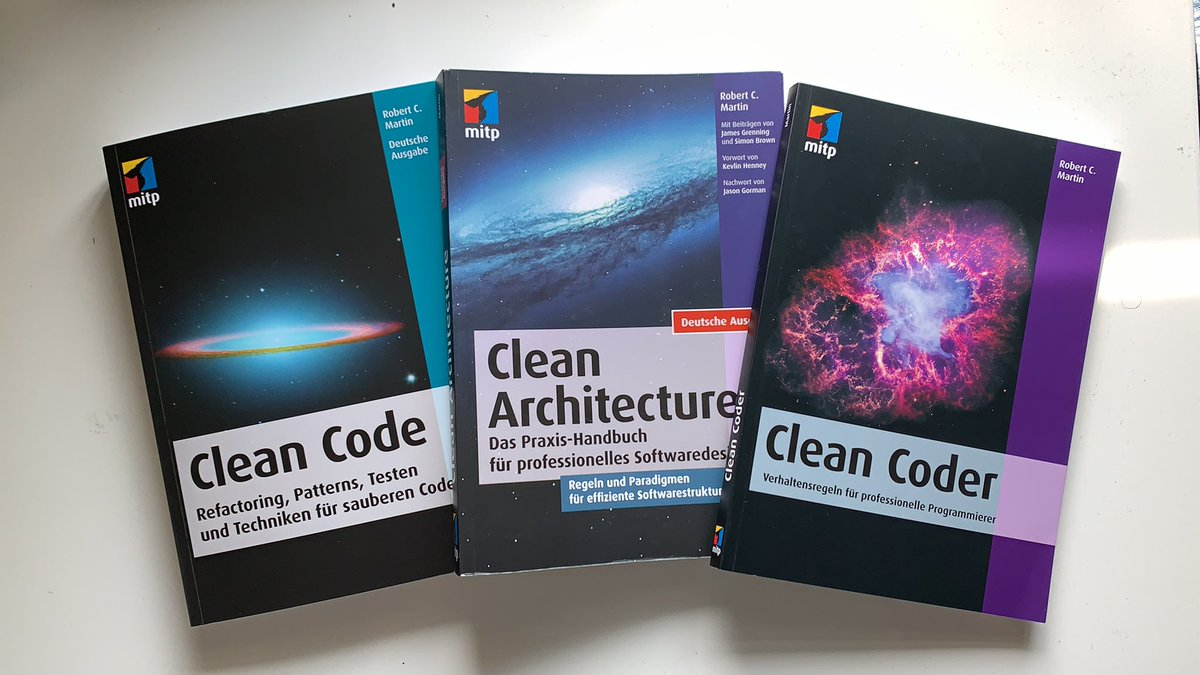

## Agenda

- Arquitectura Limpia (Clean Architecture)
- Principios de Código Limpio
- Boy Scout Rule
- Command Query Separation (CQS)
- Single Responsibility Principle (SRP)
- Dependency Rule
- Humble Object Pattern
- Transformation Priority Premise
- Four Rules of Simple Design
- STABLE Patterns

### Objetivo de la presentación

> Comprender e implementar los principios y patrones de Arquitectura Limpia en proyectos Python para crear software mantenible, escalable y de alta calidad.

# Clean Architecture

## Definición y Concepto

### ¿Qué es la Arquitectura Limpia?

- Propuesta por Robert C. Martin ("Uncle Bob")
- Enfoque para diseñar sistemas de software mantenibles y testables
- Separa las responsabilidades en capas concéntricas
- El flujo de dependencias apunta hacia adentro
- Las capas externas dependen de las internas, nunca al revés

### Beneficios

- Independencia de frameworks
- Testabilidad
- Independencia de la interfaz de usuario
- Independencia de la base de datos
- Independencia de agentes externos

## Capas de la Arquitectura Limpia

### Las cuatro capas principales

1. **Entidades** (núcleo)
   - Reglas de negocio y estructuras de datos empresariales
   - No dependen de nada externo

2. **Casos de Uso / Reglas de Negocio**
   - Lógica de aplicación específica
   - Orquesta el flujo de datos hacia y desde las entidades

3. **Adaptadores de Interfaz**
   - Convierten datos entre casos de uso y agentes externos
   - Implementan interfaces definidas por las capas internas

4. **Frameworks y Drivers**
   - Detalles externos: base de datos, web, UI, etc.
   - Capa más externa con código específico de herramientas

## Diagrama de las Capas

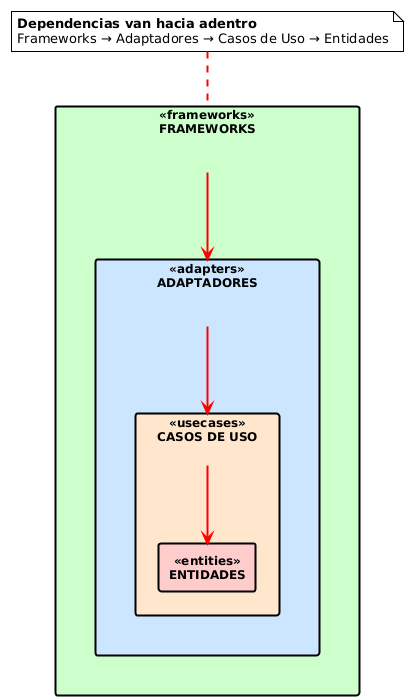

## Ejemplo en Python: Estructura de Directorios

In [ ]:
clean_app/
├── domain/                     # Capa de Entidades
│   ├── __init__.py
│   ├── entities/
│   │   ├── __init__.py
│   │   └── user.py             # Entidad User
│   └── value_objects/
│       ├── __init__.py
│       └── email.py            # Objeto de valor Email
│
├── application/                # Capa de Casos de Uso
│   ├── __init__.py
│   ├── interfaces/
│   │   ├── __init__.py
│   │   └── repositories.py     # Interfaces para repositorios
│   └── use_cases/
│       ├── __init__.py
│       └── user_service.py     # Caso de uso para gestión de usuarios
│
├── adapters/                   # Capa de Adaptadores
│   ├── __init__.py
│   ├── repositories/
│   │   ├── __init__.py
│   │   └── sqlalchemy_user_repository.py
│   └── api/
│       ├── __init__.py
│       └── flask_controllers.py
│
└── infrastructure/             # Capa de Frameworks y Drivers
    ├── __init__.py
    ├── config.py               # Configuración de la aplicación
    ├── database.py             # Configuración de la base de datos
    └── server.py               # Punto de entrada de la aplicación


## Ejemplo en Python: Implementación

### Entidad (domain/entities/user.py)

In [ ]:
class User:
    def __init__(self, user_id, name, email, password_hash):
        self.user_id = user_id
        self.name = name
        self.email = email
        self.password_hash = password_hash

    def update_name(self, name):
        self.name = name

    def update_email(self, email):
        # Podría incluir validación de email
        self.email = email


### Caso de Uso (application/use_cases/user_service.py)

In [ ]:
class UserService:
    def __init__(self, user_repository):
        self.user_repository = user_repository

    def create_user(self, name, email, password):
        # Lógica de negocio para crear un usuario
        if self.user_repository.find_by_email(email):
            raise ValueError("Email ya está en uso")
        
        password_hash = self._hash_password(password)
        user = User(None, name, email, password_hash)
        return self.user_repository.save(user)

    def _hash_password(self, password):
        # Implementación del hash
        return "hashed_" + password  # Simplificado para el ejemplo


# Principios de Código Limpio

## Definición de Código Limpio

### ¿Qué es el Código Limpio?

- Es código que es **fácil de entender** y **fácil de cambiar**
- Expresa la intención del programador de forma clara
- Es legible para otros desarrolladores
- Puede ser mantenido y extendido con esfuerzo mínimo
- No contiene duplicaciones ni complejidad innecesaria

> "Un código limpio siempre parece que fue escrito por alguien a quien le importa" - Robert C. Martin

## Principios Fundamentales

### Características del Código Limpio

- **Claridad**: Nombres significativos, funciones pequeñas
- **Simplicidad**: Hacer una cosa bien
- **Expresividad**: El código comunica su propósito
- **Minimidad**: Menos código = menos bugs
- **Testabilidad**: Fácil de probar unitariamente
- **Ausencia de duplicación**: No repetir conocimiento
- **Consistencia**: Seguir convenciones establecidas

### Prácticas clave

- Nombres descriptivos
- Funciones pequeñas con un solo propósito
- Comentarios solo cuando son necesarios
- Manejo adecuado de errores
- Tests automatizados

## Ejemplo en Python: Código "Sucio" vs. Código Limpio

### Código "Sucio"

In [ ]:
def p(d, t):
    r = []
    for i in d:
        if i['a'] > t and i['s'] == 'active':
            r.append(i)
    return r
    
# Uso
items = [
    {'id': 1, 'a': 150, 's': 'active'},
    {'id': 2, 'a': 90, 's': 'inactive'},
    {'id': 3, 'a': 120, 's': 'active'}
]
result = p(items, 100)


### Código Limpio

In [ ]:
def filter_active_items_above_threshold(items, threshold):
    """
    Filtra los ítems activos cuyo monto supera el umbral especificado.
    
    Args:
        items: Lista de ítems a filtrar
        threshold: Valor mínimo para incluir un ítem
        
    Returns:
        Lista de ítems que cumplen las condiciones
    """
    return [
        item for item in items
        if item['amount'] > threshold and item['status'] == 'active'
    ]

# Uso
items = [
    {'id': 1, 'amount': 150, 'status': 'active'},
    {'id': 2, 'amount': 90, 'status': 'inactive'},
    {'id': 3, 'amount': 120, 'status': 'active'}
]
filtered_items = filter_active_items_above_threshold(items, 100)


# Boy Scout Rule

## Definición

### "Deja el código más limpio de lo que lo encontraste"

- Inspirado en la regla de los Boy Scouts:
  > "Deja el campamento más limpio de lo que lo encontraste"

- Enfoque incremental hacia la calidad del código
- Cada desarrollador mejora pequeñas partes durante su trabajo diario
- Evita la degradación gradual del código ("entropía del software")

### Beneficios

- Mejora continua del código base
- Previene la acumulación de "deuda técnica"
- Distribuye el esfuerzo de mantenimiento
- Fomenta la propiedad colectiva del código

## Importancia en el Desarrollo Iterativo

### Aplicación práctica

- **Refactorización gradual**: Pequeñas mejoras con cada cambio
- **No reescribir**: Mejorar incrementalmente es más seguro que reescribir
- **Mantén las pruebas**: Asegura que tus mejoras no rompan la funcionalidad
- **Compromiso del equipo**: Todos deben seguir esta práctica

### Cuándo aplicar la regla

- Al añadir una nueva característica
- Al corregir un bug
- Al revisar código
- Incluso al leer código para entenderlo

## Ejemplo en Python: Refactorización Aplicando la Regla

### Código Original

In [ ]:
def process_data(data):
    result = []
    for i in range(len(data)):
        x = data[i]
        # Aplicar transformación
        if x > 10:
            x = x * 2
        elif x < 0:
            x = 0
        else:
            x = x + 1
        # Guardar resultado
        result.append(x)
    return result


### Código Mejorado (aplicando la Boy Scout Rule)

In [ ]:
def process_data(data):
    """Procesa una lista de valores numéricos según reglas específicas."""
    return [transform_value(value) for value in data]

def transform_value(value):
    """Transforma un valor individual según las siguientes reglas:
    - Si es mayor que 10, lo duplica
    - Si es negativo, devuelve 0
    - En otro caso, incrementa en 1
    """
    if value > 10:
        return value * 2
    elif value < 0:
        return 0
    else:
        return value + 1


# Command Query Separation (CQS)

## Definición del Principio

### Command Query Separation

- Principio formulado por Bertrand Meyer (creador de Eiffel)
- **Esencia del principio**: 
  > "Un método debe ser un comando que realiza una acción, o una consulta que devuelve datos, pero no ambos"

### Dos tipos de métodos:

1. **Comandos (Commands)**:
   - Realizan acciones o cambios
   - Modifican el estado observable
   - No devuelven valor (o devuelven void/None)

2. **Consultas (Queries)**:
   - Devuelven datos o información
   - No modifican el estado observable
   - Son idempotentes (pueden llamarse múltiples veces sin efectos secundarios)

## Diferencias entre Comandos y Consultas

### Comandos

- **Propósito**: Cambiar estado
- **Retorno**: Generalmente None/void (en Python)
- **Efectos secundarios**: Sí
- **Idempotencia**: No necesariamente
- **Nombre típico**: Verbo en infinitivo (crear, actualizar, eliminar)
- **Ejemplos**: `save_user()`, `update_profile()`, `delete_record()`

### Consultas

- **Propósito**: Obtener información
- **Retorno**: Datos solicitados
- **Efectos secundarios**: No
- **Idempotencia**: Sí, siempre
- **Nombre típico**: Sustantivo o pregunta (usuario, está_activo)
- **Ejemplos**: `get_user()`, `is_valid()`, `calculate_total()`

## Ejemplo en Python: Implementación de CQS

### Violación de CQS

In [ ]:
class UserRepository:
    def __init__(self):
        self.users = {}
        self.next_id = 1
    
    def add_user(self, name, email):
        """Añade un usuario y devuelve su ID"""
        user_id = self.next_id
        self.users[user_id] = {
            'id': user_id,
            'name': name,
            'email': email
        }
        self.next_id += 1
        return user_id  # Viola CQS: comando que devuelve información


### Implementación correcta con CQS

In [ ]:
class UserRepository:
    def __init__(self):
        self.users = {}
        self.next_id = 1
    
    def generate_user_id(self):
        """Query: Obtiene el próximo ID disponible"""
        return self.next_id
    
    def add_user(self, user_id, name, email):
        """Command: Añade un usuario al repositorio"""
        self.users[user_id] = {
            'id': user_id,
            'name': name,
            'email': email
        }
        self.next_id += 1
    
    def get_user(self, user_id):
        """Query: Obtiene información de un usuario"""
        return self.users.get(user_id)
    
# Uso:
repo = UserRepository()
new_id = repo.generate_user_id()  # Query: obtiene información
repo.add_user(new_id, "Juan", "juan@example.com")  # Command: modifica estado
user = repo.get_user(new_id)  # Query: obtiene información


# Single Responsibility Principle (SRP) y Arquitectura

### SRP y Clean Architecture

- Cada capa tiene una responsabilidad única y bien definida
- Las entidades solo representan conceptos de negocio
- Los casos de uso implementan reglas de negocio específicas
- Los adaptadores solo convierten datos entre formatos
- Los frameworks se aíslan en la capa externa

### Señales de violación de SRP

- Clases grandes con muchos métodos
- Métodos que manipulan datos no relacionados con la clase
- Cambios frecuentes por razones diferentes
- Alto acoplamiento entre componentes
- Nombres de clase vagos o demasiado generales

## Ejemplo en Python: Refactorización con SRP

### Clase que viola SRP

### Refactorización aplicando SRP

# Dependency Rule

### Principio fundamental de Clean Architecture

> "Las dependencias del código fuente solo pueden apuntar hacia adentro"

### Reglas clave

- Las capas internas no conocen nada sobre las capas externas
- Los formatos de datos usados en capas externas no deben ser usados por capas internas
- Las entidades son independientes de todo lo demás
- Las capas externas pueden conocer a las internas, pero no al revés

### Beneficios

- **Aislamiento**: Cambios en sistemas externos no afectan el núcleo
- **Testabilidad**: Se pueden probar componentes sin dependencias externas
- **Flexibilidad**: Fácil reemplazar componentes externos (BD, UI, frameworks)
- **Evolución**: El sistema puede evolucionar sin afectar reglas de negocio

## Flujo de Control vs. Flujo de Dependencia

### Flujo de Control

- Dirección en la que se ejecutan las llamadas en tiempo de ejecución
- Puede ir desde las capas externas hacia las internas y viceversa
- Ejemplo: API Controller → Use Case → Entity → Use Case → Repository → Database

### Flujo de Dependencia

- Dirección en la que apuntan las dependencias en el código fuente
- **Siempre** debe apuntar hacia adentro (hacia las capas internas)
- Ejemplo: API Controller → Use Case ← Repository → Database
- El código interno *nunca* debe importar código externo

### Inversión de Dependencia

- Permite que el flujo de control vaya hacia afuera mientras que el flujo de dependencia se mantiene hacia adentro
- Usa interfaces/abstracciones definidas en capas internas
- Implementaciones concretas en capas externas

# Humble Object Pattern

- Patrón de diseño que separa el código difícil de probar del código fácil de probar
- Extrae la lógica compleja y de negocio de componentes que dependen de elementos difíciles de probar (UI, BD, red)
- Crea objetos "humildes" que hacen poco más que delegar a otros componentes probables

### Propósito

- Mejorar la testabilidad del sistema
- Separar claramente la lógica de negocio de detalles técnicos
- Facilitar pruebas unitarias sin dependencias complejas
- Reducir la complejidad de componentes difíciles de probar

### Origen

- Creado por Gerard Meszaros en el contexto de pruebas unitarias
- Evolucionado como patrón clave en arquitecturas limpias

## Casos de Uso Comunes

### Humble Views (UI)

- La vista se convierte en un objeto "humilde" que solo muestra datos y captura eventos
- Toda la lógica se extrae a un Presentador/ViewModel/Controlador

### Humble Controllers (Web)

- El controlador web se limita a extraer parámetros HTTP y convertir respuestas
- Delega toda la lógica real a servicios de aplicación probables

### Humble Database Adapters

- Adaptadores de BD simples que solo manejan conexión/consultas
- La lógica de mapeo y negocio se extrae a servicios independientes

### Testing Frameworks

- Wrappers "humildes" alrededor de frameworks de prueba
- Facilitan el testing de componentes principales sin dependencias directas

## Ejemplo en Python: Separación de Lógica de Negocios y UI

### Enfoque Tradicional (sin Humble Object)

In [ ]:
class OrderFormHandler:
    def __init__(self):
        self.order_items = []
        # Elementos de la UI
        self.product_dropdown = ProductDropdown()
        self.quantity_input = QuantityInput()
        self.add_button = Button("Añadir")
        self.checkout_button = Button("Comprar")
        
        # Configurar eventos
        self.add_button.on_click(self.add_item)
        self.checkout_button.on_click(self.process_order)
    
    def add_item(self):
        product = self.product_dropdown.get_selected_product()
        quantity = self.quantity_input.get_value()
        
        # Validación y lógica de negocio
        if quantity <= 0:
            self.show_error("La cantidad debe ser mayor que cero")
            return
            
        if product.stock < quantity:
            self.show_error(f"Stock insuficiente. Solo hay {product.stock} unidades")
            return
            
        # Calcular subtotal con descuentos
        price = product.price
        if quantity > 10:
            price = price * 0.9  # 10% descuento
            
        self.order_items.append({
            'product': product,
            'quantity': quantity,
            'subtotal': price * quantity
        })
        
        self.update_order_summary()
    
    def process_order(self):
        if not self.order_items:
            self.show_error("El carrito está vacío")
            return
            
        total = sum(item['subtotal'] for item in self.order_items)
        
        # Aplica impuestos
        tax = total * 0.16
        final_total = total + tax
        
        # Procesar pago
        payment_result = self.process_payment(final_total)
        if payment_result['success']:
            self.update_inventory()
            self.show_success("¡Orden procesada correctamente!")
        else:
            self.show_error(f"Error de pago: {payment_result['error']}")
    
    # Métodos relacionados con UI
    def show_error(self, message):
        # Código para mostrar error en la UI
        pass
        
    def show_success(self, message):
        # Código para mostrar mensaje de éxito
        pass
        
    def update_order_summary(self):
        # Actualizar UI con resumen de la orden
        pass


### Aplicando Humble Object Pattern

In [ ]:
# Lógica de negocio pura (fácil de probar)
class OrderService:
    def __init__(self, inventory_service, payment_service):
        self.inventory_service = inventory_service
        self.payment_service = payment_service
    
    def validate_item_addition(self, product, quantity):
        if quantity <= 0:
            return {"valid": False, "error": "La cantidad debe ser mayor que cero"}
            
        if product.stock < quantity:
            return {"valid": False, "error": f"Stock insuficiente. Solo hay {product.stock} unidades"}
            
        return {"valid": True}
    
    def calculate_item_price(self, product, quantity):
        price = product.price
        if quantity > 10:
            price = price * 0.9  # 10% descuento
        return price
    
    def calculate_order_total(self, items):
        subtotal = sum(item['subtotal'] for item in items)
        tax = subtotal * 0.16
        return {
            "subtotal": subtotal,
            "tax": tax,
            "total": subtotal + tax
        }
    
    def process_order(self, items):
        if not items:
            return {"success": False, "error": "El carrito está vacío"}
        
        # Calcular totales
        totals = self.calculate_order_total(items)
        
        # Verificar inventario
        for item in items:
            if not self.inventory_service.check_availability(item['product'].id, item['quantity']):
                return {"success": False, "error": f"Producto {item['product'].name} ya no disponible"}
        
        # Procesar pago
        payment_result = self.payment_service.process(totals["total"])
        if not payment_result["success"]:
            return payment_result
        
        # Actualizar inventario
        for item in items:
            self.inventory_service.reduce_stock(item['product'].id, item['quantity'])
        
        return {"success": True, "order_total": totals["total"]}

# Objeto "humilde" - Maneja solo la UI y delega lógica
class OrderFormHandler:
    def __init__(self, order_service):
        self.order_service = order_service
        self.order_items = []
        
        # Elementos de la UI
        self.product_dropdown = ProductDropdown()
        self.quantity_input = QuantityInput()
        self.add_button = Button("Añadir")
        self.checkout_button = Button("Comprar")
        
        # Configurar eventos
        self.add_button.on_click(self.add_item)
        self.checkout_button.on_click(self.process_order)
    
    def add_item(self):
        product = self.product_dropdown.get_selected_product()
        quantity = self.quantity_input.get_value()
        
        # Delega validación al servicio
        validation = self.order_service.validate_item_addition(product, quantity)
        if not validation["valid"]:
            self.show_error(validation["error"])
            return
        
        # Delega cálculo de precio
        price = self.order_service.calculate_item_price(product, quantity)
        
        # Añadir al carrito
        self.order_items.append({
            'product': product,
            'quantity': quantity,
            'subtotal': price * quantity
        })
        
        self.update_order_summary()
    
    def process_order(self):
        # Delega todo el procesamiento al servicio
        result = self.order_service.process_order(self.order_items)
        
        if result["success"]:
            self.show_success("¡Orden procesada correctamente!")
            self.clear_form()
        else:
            self.show_error(f"Error: {result['error']}")
    
    # Métodos de UI
    def show_error(self, message):
        # Código para mostrar error en la UI
        pass
        
    def show_success(self, message):
        # Código para mostrar mensaje de éxito
        pass
        
    def update_order_summary(self):
        # Actualizar UI con resumen de la orden
        totals = self.order_service.calculate_order_total(self.order_items)
        # Actualizar elementos visuales con los totales
        pass
        
    def clear_form(self):
        # Limpiar formulario después de procesar orden
        self.order_items = []
        self.update_order_summary()


# Transformation Priority Premise

- Propuesta por Robert C. Martin ("Uncle Bob")
- Guía para el desarrollo incremental usando TDD (Test-Driven Development)
- Sugiere un orden específico de transformaciones de código para evitar callejones sin salida
- Ayuda a escribir código más simple y mantenible de forma incremental

### Propósito

- **Evitar sobre-ingeniería**: Implementar solo lo necesario para pasar el test actual
- **Progresión natural**: Evolucionar el código de manera orgánica
- **Menor complejidad**: Cada transformación añade la mínima complejidad necesaria
- **Predictibilidad**: Tener un camino claro para implementar funcionalidad

### Filosofía

> "Para transformar código simple en código más general, existe un orden natural que, si se sigue, evita callejones sin salida y refactorizaciones complejas"

## Lista de Transformaciones Ordenadas por Prioridad

### Las Transformaciones (de mayor a menor prioridad)

1. **{} → nil** (ningún código → código que devuelve nil/null)
2. **nil → constant** (devolver constante en lugar de nil)
3. **constant → constant+** (constante simple → expresión constante)
4. **constant → scalar** (constante → variable escalar)
5. **statement → statements** (una sentencia → múltiples sentencias)
6. **unconditional → if** (código sin condiciones → código condicional)
7. **scalar → array** (variable escalar → colección)
8. **array → container** (array simple → estructura de datos compleja)
9. **statement → recursion** (sentencia → llamada recursiva)
10. **if → while** (condición → bucle)
11. **expression → function** (expresión → llamada a función)
12. **variable → assignment** (usar variable → asignar a variable)

### Principios de aplicación

- Usar la transformación de **mayor prioridad** que haga pasar el test
- Evitar saltar a transformaciones de menor prioridad prematuramente
- Si te encuentras en un callejón sin salida, retrocede y usa una transformación de mayor prioridad

## Ejemplo en Python: Desarrollo Guiado por Transformaciones

### Caso: Implementar una función para calcular factorial

#### Test 1: Caso más simple

In [ ]:
def test_factorial_of_zero():
    assert factorial(0) == 1

# Transformación 1: {} → nil
def factorial(n):
    pass  # No hace nada

# Transformación 2: nil → constant  
def factorial(n):
    return 1  # Devuelve constante


#### Test 2: Factorial de 1

In [ ]:
def test_factorial_of_one():
    assert factorial(1) == 1

# El código actual ya pasa, no necesita cambios
def factorial(n):
    return 1


#### Test 3: Factorial de 2

In [ ]:
def test_factorial_of_two():
    assert factorial(2) == 2

# Transformación 6: unconditional → if
def factorial(n):
    if n <= 1:
        return 1
    return 2  # Constante para hacer pasar el test


#### Test 4: Factorial de 3

In [ ]:
def test_factorial_of_three():
    assert factorial(3) == 6

# Transformación 3: constant → constant+
def factorial(n):
    if n <= 1:
        return 1
    if n == 2:
        return 2
    return 6  # Otra constante


#### Test 5: Generalizar - Factorial de 4

In [ ]:
def test_factorial_of_four():
    assert factorial(4) == 24

# Transformación 4: constant → scalar
# Transformación 12: variable → assignment
def factorial(n):
    if n <= 1:
        return 1
    result = 1
    current = 2
    # Transformación 10: if → while
    while current <= n:
        result = result * current
        current = current + 1
    return result


#### Versión final usando recursión

In [ ]:
def test_factorial_of_five():
    assert factorial(5) == 120

# Transformación 9: statement → recursion
def factorial(n):
    if n <= 1:
        return 1
    return n * factorial(n - 1)


# Four Rules of Simple Design (Kent Beck)

### Origen y Contexto

- Formuladas por Kent Beck (creador de XP y TDD)
- Parte de la metodología Extreme Programming
- Guían hacia un diseño simple y efectivo
- **Orden de prioridad**: Las reglas están ordenadas por importancia

### Las Cuatro Reglas (en orden de prioridad)

1. **Pasa todos los tests**
   - El código debe funcionar correctamente
   - Prioridad máxima: sin funcionalidad correcta, nada más importa

2. **Expresa intención (revela propósito)**
   - El código debe comunicar claramente qué hace y por qué
   - Nombres significativos, estructura clara

3. **Sin duplicación (DRY - Don't Repeat Yourself)**
   - Eliminar conocimiento duplicado
   - Una sola fuente de verdad para cada concepto

4. **Minimiza clases y métodos**
   - Menos código = menos complejidad
   - Solo después de cumplir las tres reglas anteriores

### Filosofía

> "Un diseño es simple cuando no se puede quitar nada más sin perder funcionalidad o claridad"

## Aplicación Práctica de las Reglas

### Proceso iterativo

1. **Hacer que funcione** (Tests verdes)
2. **Hacer que sea claro** (Refactorizar para expresividad)
3. **Eliminar duplicación** (DRY)
4. **Simplificar** (Minimizar elementos innecesarios)

### Señales de violación

- **Regla 1**: Tests fallan o no existen
- **Regla 2**: Nombres poco claros, funciones largas, responsabilidades mixtas
- **Regla 3**: Código similar en múltiples lugares
- **Regla 4**: Clases/métodos que no añaden valor

### Beneficios

- Código mantenible y evolutivo
- Menor costo de cambio
- Mayor confianza en modificaciones
- Comunicación efectiva entre desarrolladores

## Ejemplo en Python: Aplicando las Cuatro Reglas

### Código inicial (viola las reglas)

In [ ]:
class Calculator:
    def add_numbers(self, x, y):
        result = x + y
        print(f"Adding {x} and {y}")
        print(f"Result: {result}")
        return result
    
    def subtract_numbers(self, x, y):
        result = x - y
        print(f"Subtracting {y} from {x}")
        print(f"Result: {result}")
        return result
    
    def multiply_numbers(self, x, y):
        result = x * y
        print(f"Multiplying {x} and {y}")
        print(f"Result: {result}")
        return result
    
    def calculate_rectangle_area(self, width, height):
        area = width * height
        print(f"Calculating area of rectangle {width}x{height}")
        print(f"Area: {area}")
        return area
    
    def calculate_triangle_area(self, base, height):
        area = (base * height) / 2
        print(f"Calculating area of triangle base={base}, height={height}")
        print(f"Area: {area}")
        return area

# Tests inexistentes o inadecuados
def test_calculator():
    calc = Calculator()
    # Test incompleto
    assert calc.add_numbers(2, 3) == 5


### Aplicando las Cuatro Reglas

#### Regla 1: Pasa todos los tests

In [ ]:
import pytest

class Calculator:
    def add_numbers(self, x, y):
        result = x + y
        print(f"Adding {x} and {y}")
        print(f"Result: {result}")
        return result
    
    def subtract_numbers(self, x, y):
        result = x - y
        print(f"Subtracting {y} from {x}")
        print(f"Result: {result}")
        return result
    
    def multiply_numbers(self, x, y):
        result = x * y
        print(f"Multiplying {x} and {y}")
        print(f"Result: {result}")
        return result

# Tests completos
def test_calculator_operations():
    calc = Calculator()
    assert calc.add_numbers(2, 3) == 5
    assert calc.add_numbers(-1, 1) == 0
    assert calc.subtract_numbers(5, 3) == 2
    assert calc.subtract_numbers(1, 5) == -4
    assert calc.multiply_numbers(3, 4) == 12
    assert calc.multiply_numbers(-2, 3) == -6


#### Regla 2: Expresa intención

In [ ]:
class MathCalculator:
    def add(self, first_number, second_number):
        sum_result = first_number + second_number
        self._log_operation("addition", first_number, second_number, sum_result)
        return sum_result
    
    def subtract(self, minuend, subtrahend):
        difference = minuend - subtrahend
        self._log_operation("subtraction", minuend, subtrahend, difference)
        return difference
    
    def multiply(self, multiplicand, multiplier):
        product = multiplicand * multiplier
        self._log_operation("multiplication", multiplicand, multiplier, product)
        return product
    
    def _log_operation(self, operation_name, first_operand, second_operand, result):
        print(f"Performing {operation_name}: {first_operand} and {second_operand}")
        print(f"Result: {result}")


#### Regla 3: Sin duplicación

In [ ]:
class MathCalculator:
    def add(self, first_number, second_number):
        return self._execute_operation(
            operation=lambda x, y: x + y,
            operation_name="addition",
            first_operand=first_number,
            second_operand=second_number
        )
    
    def subtract(self, minuend, subtrahend):
        return self._execute_operation(
            operation=lambda x, y: x - y,
            operation_name="subtraction", 
            first_operand=minuend,
            second_operand=subtrahend
        )
    
    def multiply(self, multiplicand, multiplier):
        return self._execute_operation(
            operation=lambda x, y: x * y,
            operation_name="multiplication",
            first_operand=multiplicand,
            second_operand=multiplier
        )
    
    def _execute_operation(self, operation, operation_name, first_operand, second_operand):
        result = operation(first_operand, second_operand)
        self._log_operation(operation_name, first_operand, second_operand, result)
        return result
    
    def _log_operation(self, operation_name, first_operand, second_operand, result):
        print(f"Performing {operation_name}: {first_operand} and {second_operand}")
        print(f"Result: {result}")


#### Regla 4: Minimiza clases y métodos

In [ ]:
from typing import Callable

class Calculator:
    def __init__(self, logger=None):
        self.logger = logger or self._default_logger
    
    def add(self, x, y):
        return self._calculate("addition", lambda a, b: a + b, x, y)
    
    def subtract(self, x, y):
        return self._calculate("subtraction", lambda a, b: a - b, x, y)
    
    def multiply(self, x, y):
        return self._calculate("multiplication", lambda a, b: a * b, x, y)
    
    def _calculate(self, operation_name: str, operation: Callable, x, y):
        result = operation(x, y)
        self.logger(operation_name, x, y, result)
        return result
    
    def _default_logger(self, operation_name, x, y, result):
        print(f"Performing {operation_name}: {x} and {y} = {result}")

# Tests siguen pasando
def test_calculator_operations():
    calc = Calculator()
    assert calc.add(2, 3) == 5
    assert calc.subtract(5, 3) == 2
    assert calc.multiply(3, 4) == 12


# STABLE Patterns

- Acrónimo que describe características de arquitecturas sólidas y sostenibles
- Proporciona una guía para evaluar y diseñar sistemas de software
- Enfoque holístico que va más allá de principios individuales
- Marco de referencia para arquitecturas "estables" en el tiempo

### Origen y Contexto

- Evolución de principios de arquitectura de software
- Síntesis de mejores prácticas de la industria
- Enfoque en la **estabilidad** y **sostenibilidad** a largo plazo
- Complementa otros frameworks como SOLID

### Beneficios de aplicar STABLE

- Sistemas más resilientes al cambio
- Arquitecturas que evolucionan graciosamente
- Menor deuda técnica acumulada
- Mayor facilidad de mantenimiento y extensión

## Desglose de cada Componente

### S - Solid (Principios SOLID)

**Single Responsibility, Open/Closed, Liskov Substitution, Interface Segregation, Dependency Inversion**

- Base fundamental para clases y módulos bien diseñados
- Garantiza cohesión alta y acoplamiento bajo
- Facilita testabilidad y mantenimiento

### T - Testable (Fácil de Probar)

- El código debe ser diseñado para ser probado desde el inicio
- Dependencias inyectables y mockeables
- Lógica de negocio separada de infraestructura

### A - Adaptable (Flexible al Cambio)

- Capacidad de evolucionar sin ruptura masiva
- Interfaces estables, implementaciones flexibles
- Configuración external para comportamientos variables

### B - Boundaries (Límites Claros)

- Separación clara entre capas y componentes
- Interfaces bien definidas entre subsistemas
- Aislamiento de dependencias externas

### L - Libraries over Frameworks (Preferir Librerías)

- Mantener control sobre el flujo de la aplicación
- Evitar vendor lock-in y dependencias invasivas
- Inversión de control en manos del desarrollador

### E - Evolutionary Architecture (Arquitectura Evolutiva)

- Diseño que anticipa y facilita el cambio
- Métricas y fitness functions para guiar evolución
- Incrementalidad sobre big bang rewrites

## Ejemplos en Python para cada Componente

### S - SOLID: Single Responsibility Principle

In [ ]:
# Violación de SRP
class EmailUser:
    def __init__(self, email, password):
        self.email = email
        self.password = password
    
    def send_email(self, to, subject, body):
        # Lógica de envío de email
        pass
    
    def validate_email_format(self):
        # Validación de formato
        return '@' in self.email
    
    def hash_password(self):
        # Hash de contraseña
        import hashlib
        return hashlib.sha256(self.password.encode()).hexdigest()

# Aplicando SRP
class User:
    def __init__(self, email, password_hash):
        self.email = email
        self.password_hash = password_hash

class EmailValidator:
    @staticmethod
    def is_valid(email):
        return '@' in email and '.' in email

class PasswordHasher:
    @staticmethod
    def hash(password):
        import hashlib
        return hashlib.sha256(password.encode()).hexdigest()

class EmailService:
    def send(self, to, subject, body):
        # Lógica de envío
        pass


### T - Testable: Inyección de Dependencias

In [ ]:
# Difícil de probar
class OrderProcessor:
    def process_order(self, order):
        # Dependencia hard-coded
        payment_service = PayPalPaymentService()
        inventory_service = DatabaseInventoryService()
        
        if not inventory_service.check_stock(order.items):
            return False
            
        return payment_service.process_payment(order.total)

# Fácil de probar
class OrderProcessor:
    def __init__(self, payment_service, inventory_service):
        self.payment_service = payment_service
        self.inventory_service = inventory_service
    
    def process_order(self, order):
        if not self.inventory_service.check_stock(order.items):
            return False
            
        return self.payment_service.process_payment(order.total)

# Test con mocks
def test_order_processing():
    mock_payment = Mock()
    mock_inventory = Mock()
    mock_inventory.check_stock.return_value = True
    mock_payment.process_payment.return_value = True
    
    processor = OrderProcessor(mock_payment, mock_inventory)
    order = Order(items=[...], total=100)
    
    result = processor.process_order(order)
    
    assert result is True
    mock_inventory.check_stock.assert_called_once()
    mock_payment.process_payment.assert_called_once_with(100)


### A - Adaptable: Strategy Pattern

In [ ]:
from abc import ABC, abstractmethod

class PricingStrategy(ABC):
    @abstractmethod
    def calculate_price(self, base_price, customer):
        pass

class RegularPricingStrategy(PricingStrategy):
    def calculate_price(self, base_price, customer):
        return base_price

class PremiumPricingStrategy(PricingStrategy):
    def calculate_price(self, base_price, customer):
        return base_price * 0.9  # 10% descuento

class VIPPricingStrategy(PricingStrategy):
    def calculate_price(self, base_price, customer):
        return base_price * 0.8  # 20% descuento

class PriceCalculator:
    def __init__(self, strategy: PricingStrategy):
        self.strategy = strategy
    
    def calculate(self, base_price, customer):
        return self.strategy.calculate_price(base_price, customer)
    
    def set_strategy(self, strategy: PricingStrategy):
        self.strategy = strategy

# Uso adaptable
calculator = PriceCalculator(RegularPricingStrategy())
price = calculator.calculate(100, customer)

# Cambio dinámico de estrategia
if customer.is_vip():
    calculator.set_strategy(VIPPricingStrategy())


### B - Boundaries: Puertos y Adaptadores

In [ ]:
# Puerto - Interfaz que define el boundary
from abc import ABC, abstractmethod

class UserRepository(ABC):
    @abstractmethod
    def save(self, user):
        pass
    
    @abstractmethod
    def find_by_email(self, email):
        pass

# Adaptador para base de datos
class SQLiteUserRepository(UserRepository):
    def __init__(self, connection):
        self.connection = connection
    
    def save(self, user):
        cursor = self.connection.cursor()
        cursor.execute(
            "INSERT INTO users (email, name) VALUES (?, ?)",
            (user.email, user.name)
        )
    
    def find_by_email(self, email):
        cursor = self.connection.cursor()
        cursor.execute("SELECT * FROM users WHERE email = ?", (email,))
        return cursor.fetchone()

# Adaptador para API externa
class APIUserRepository(UserRepository):
    def __init__(self, api_client):
        self.api_client = api_client
    
    def save(self, user):
        return self.api_client.post('/users', user.to_dict())
    
    def find_by_email(self, email):
        return self.api_client.get(f'/users/by-email/{email}')

# El dominio no conoce los detalles de implementación
class UserService:
    def __init__(self, user_repository: UserRepository):
        self.user_repository = user_repository
    
    def register_user(self, email, name):
        if self.user_repository.find_by_email(email):
            raise ValueError("Email already exists")
        
        user = User(email=email, name=name)
        return self.user_repository.save(user)


### L - Libraries over Frameworks: Composition Root

In [ ]:
# En lugar de usar un framework pesado que controle tu aplicación
# Usar librerías y mantener el control

# Composición manual vs framework IoC
class Application:
    def __init__(self):
        # Wire-up manual de dependencias (Composition Root)
        self.db_connection = sqlite3.connect('app.db')
        self.user_repository = SQLiteUserRepository(self.db_connection)
        self.email_service = SMTPEmailService()
        self.user_service = UserService(self.user_repository, self.email_service)
        
        # Usar librerías para funcionalidad específica
        self.web_server = create_simple_server(host='localhost', port=8080)
        self.json_parser = json  # librería estándar
        self.http_client = requests  # librería, no framework
    
    def handle_request(self, request_data):
        # Tu aplicación controla el flujo
        data = self.json_parser.loads(request_data)
        result = self.user_service.process_user_data(data)
        return self.json_parser.dumps(result)

# Configuración de librerías en lugar de framework config
def configure_logging():
    import logging
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
    )

def configure_database():
    conn = sqlite3.connect('app.db')
    conn.execute('''CREATE TABLE IF NOT EXISTS users 
                   (id INTEGER PRIMARY KEY, email TEXT, name TEXT)''')
    return conn


### E - Evolutionary Architecture: Fitness Functions

In [ ]:
import ast
import inspect
from typing import List, Dict

# Fitness Functions para medir salud arquitectural
class ArchitecturalFitnessTests:
    
    def test_no_circular_dependencies(self, modules: List[str]) -> bool:
        """Verifica que no haya dependencias circulares entre módulos"""
        dependencies = self._extract_dependencies(modules)
        return not self._has_cycles(dependencies)
    
    def test_layer_dependency_rule(self, source_files: List[str]) -> bool:
        """Verifica que las capas respeten la regla de dependencia"""
        violations = []
        
        for file_path in source_files:
            layer = self._identify_layer(file_path)
            imports = self._extract_imports(file_path)
            
            for import_path in imports:
                import_layer = self._identify_layer(import_path)
                if not self._is_valid_dependency(layer, import_layer):
                    violations.append(f"{file_path} -> {import_path}")
        
        return len(violations) == 0
    
    def test_maximum_class_size(self, classes: List, max_lines: int = 200) -> bool:
        """Verifica que las clases no excedan un tamaño máximo"""
        violations = []
        
        for cls in classes:
            source_lines = len(inspect.getsource(cls).split('\n'))
            if source_lines > max_lines:
                violations.append(f"{cls.__name__}: {source_lines} lines")
        
        return len(violations) == 0
    
    def test_test_coverage_threshold(self, coverage_percentage: float, threshold: float = 80.0) -> bool:
        """Verifica que la cobertura de tests supere el umbral"""
        return coverage_percentage >= threshold
    
    def _identify_layer(self, file_path: str) -> str:
        """Identifica a qué capa pertenece un archivo"""
        if 'domain' in file_path:
            return 'domain'
        elif 'application' in file_path:
            return 'application'
        elif 'infrastructure' in file_path:
            return 'infrastructure'
        elif 'adapters' in file_path:
            return 'adapters'
        return 'unknown'
    
    def _is_valid_dependency(self, from_layer: str, to_layer: str) -> bool:
        """Verifica si una dependencia entre capas es válida"""
        layer_hierarchy = {
            'infrastructure': ['adapters', 'application', 'domain'],
            'adapters': ['application', 'domain'],
            'application': ['domain'],
            'domain': []
        }
        
        return to_layer in layer_hierarchy.get(from_layer, [])

# Métricas evolutivas
class EvolutionaryMetrics:
    def __init__(self):
        self.fitness_tests = ArchitecturalFitnessTests()
    
    def run_architectural_fitness_suite(self) -> Dict[str, bool]:
        """Ejecuta todas las pruebas de fitness arquitectural"""
        results = {}
        
        # Estas pruebas se ejecutarían en CI/CD
        results['no_circular_dependencies'] = self.fitness_tests.test_no_circular_dependencies([])
        results['layer_dependency_rule'] = self.fitness_tests.test_layer_dependency_rule([])
        results['class_size_limit'] = self.fitness_tests.test_maximum_class_size([])
        results['test_coverage'] = self.fitness_tests.test_test_coverage_threshold(85.0)
        
        return results
    
    def calculate_architecture_health_score(self) -> float:
        """Calcula un puntaje general de salud arquitectural"""
        results = self.run_architectural_fitness_suite()
        passed_tests = sum(1 for result in results.values() if result)
        total_tests = len(results)
        
        return (passed_tests / total_tests) * 100.0

# Uso en pipeline de CI/CD
def check_architectural_fitness():
    metrics = EvolutionaryMetrics()
    health_score = metrics.calculate_architecture_health_score()
    
    if health_score < 80.0:
        raise Exception(f"Architectural fitness below threshold: {health_score}%")
    
    print(f"Architecture health score: {health_score}%")


# Interrelación entre Conceptos

## Diagrama de Relaciones entre Conceptos

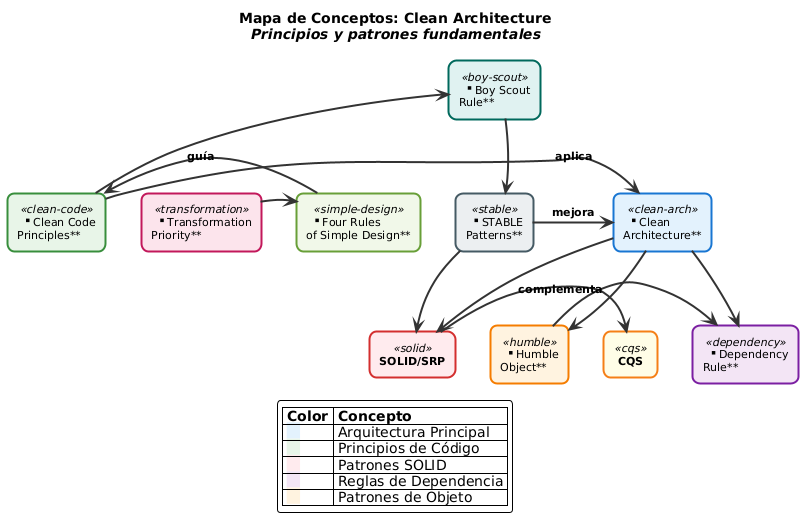

## Enfoque Unificado para Aplicar Todos los Principios

### Marco de Aplicación Integral

#### 1. **Fundación: Clean Code + SOLID**
- Empezar con código limpio y principios SOLID
- Establecer bases sólidas para construcción incremental
- **Boy Scout Rule**: Mejora continua del código base

#### 2. **Estructura: Clean Architecture**
- Organizar el sistema en capas con **Dependency Rule**
- Separar responsabilidades claramente (**SRP**)
- Aplicar **Humble Object Pattern** para aislar complejidad

#### 3. **Diseño de Interfaces: CQS**
- Separar comandos de consultas en todas las capas
- Crear interfaces claras y predecibles
- Facilitar testing y mantenimiento

#### 4. **Desarrollo Incremental**
- **Transformation Priority Premise**: Evolución natural del código
- **Four Rules of Simple Design**: Guía para decisiones de diseño
- TDD como metodología de desarrollo

#### 5. **Arquitectura Sostenible: STABLE**
- Evaluación continua de la salud arquitectural
- Métricas y fitness functions para guiar evolución
- Enfoque en estabilidad a largo plazo

### Sinergia entre Principios

#### Cómo se Refuerzan Mutuamente

**Clean Architecture + SOLID**:
- SRP define responsabilidades por capa
- Dependency Rule implementa Dependency Inversion
- Interface Segregation crea contratos claros entre capas

**CQS + Humble Object**:
- CQS simplifica interfaces de objetos humildes
- Comandos se delegan a servicios especializados
- Consultas permanecen en objetos humildes para UI

**Boy Scout Rule + Transformation Priority**:
- Boy Scout impulsa mejoras incrementales
- Transformation Priority guía **cómo** hacer esas mejoras
- Evita over-engineering en refactorizaciones

**Four Rules + STABLE**:
- Four Rules guían decisiones locales de diseño  
- STABLE evalúa impacto arquitectural global
- Fitness functions automatizan verificación de reglas

### Beneficios del Enfoque Unificado

#### Ventajas Compuestas

1. **Mantenibilidad Exponencial**
   - Cada principio amplifica los beneficios de los otros
   - Cambios locales no rompen arquitectura global

2. **Evolución Controlada**
   - Transformation Priority + Boy Scout = mejora predecible
   - STABLE metrics + Clean Architecture = evolución sostenible

3. **Testing Integral**
   - Humble Object facilita mocking
   - CQS simplifica aserciones de test
   - Clean Architecture permite testing por capas

4. **Onboarding Simplificado**
   - Desarrolladores nuevos entienden estructura clara
   - Principios aplicados consistentemente
   - Patrones reconocibles en toda la aplicación

## Preguntas Frecuentes

### ¿Cómo empezar a aplicar estos principios en un proyecto existente?

1. **Comenzar con Boy Scout Rule** - Mejorar gradualmente el código que tocas
2. **Aplicar Clean Code** - Empezar con nombres y funciones pequeñas
3. **Introducir tests** - Crear safety net para refactorizaciones
4. **Extraer capas gradualmente** - No reescribir todo de una vez

### ¿Cuál es el orden recomendado para aprender estos conceptos?

1. Clean Code Principles (base fundamental)
2. SOLID Principles (especialmente SRP)
3. Clean Architecture (estructura general)
4. Patrones específicos (CQS, Humble Object, etc.)
5. Principios evolutivos (STABLE, Four Rules)

### ¿Cómo medir el éxito de la aplicación de estos principios?

- **Métricas de calidad:** Cobertura de tests, complejidad ciclomática
- **Velocidad de desarrollo:** Tiempo para implementar nuevas features
- **Facilidad de mantenimiento:** Tiempo para hacer cambios
- **Onboarding:** Tiempo que toma a nuevos desarrolladores ser productivos

### ¿Estos principios son aplicables a todos los tipos de proyectos?

- **Proyectos grandes/medianos:** Totalmente recomendado
- **Prototipos/MVP:** Aplicar selectivamente (Clean Code siempre)
- **Scripts pequeños:** Principios básicos (nombres claros, funciones pequeñas)
- **Sistemas críticos:** Esencial para mantenibilidad y calidad